# Experiments 1 & 2 — Combined Figure with Curve Fits

This notebook benchmarks the methods from Section 1 / Figure 2 of <File>Poster___numerical_linear_algebra (3).pdf</File> and adds two fitted models for **all cases**:

1. `t(n) = a * n^b` where `a` and `b` are estimated.
2. `t(n) = c * n^3` where `c` is estimated.

The method families are:
- Dense: LU, Matrix Inverse, QR
- SPD: Cholesky, LU, Matrix Inverse, QR

The benchmark sizes are:
`n = 50, 100, 200, 400, 800`


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.linalg import lu_factor, lu_solve, cho_factor, cho_solve
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')


## Matrix generators

In [15]:
def generate_general_dense(n: int, rng: np.random.Generator):
    A = rng.standard_normal((n, n)) + 5.0 * np.eye(n)
    b = rng.standard_normal(n)
    return A, b


def generate_spd_matrix(n: int, rng: np.random.Generator, alpha: float = 1e-2):
    M = rng.standard_normal((n, n))
    A = M.T @ M + alpha * n * np.eye(n)
    b = rng.standard_normal(n)
    return A, b


## Solvers

In [16]:
def solve_lu(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    lu, piv = lu_factor(A, check_finite=False)
    return lu_solve((lu, piv), b, check_finite=False)


def solve_matrix_inverse(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.linalg.inv(A) @ b


def solve_qr(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    Q, R = np.linalg.qr(A)
    return np.linalg.solve(R, Q.T @ b)


def solve_cholesky(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    c, low = cho_factor(A, lower=True, check_finite=False)
    return cho_solve((c, low), b, check_finite=False)


METHODS_DENSE = {
    'Dense - LU': solve_lu,
    'Dense - MatrixInverse': solve_matrix_inverse,
    'Dense - QR': solve_qr,
}

METHODS_SPD = {
    'SPD - Cholesky': solve_cholesky,
    'SPD - LU': solve_lu,
    'SPD - MatrixInverse': solve_matrix_inverse,
    'SPD - QR': solve_qr,
}


## Benchmark helpers

In [17]:
def benchmark_solver(solver, A: np.ndarray, b: np.ndarray, repeats: int = 3, warmups: int = 1):
    for _ in range(warmups):
        solver(A, b)

    timings = []
    x_last = None
    for _ in range(repeats):
        t0 = perf_counter()
        x_last = solver(A, b)
        timings.append(perf_counter() - t0)

    x_ref = np.linalg.solve(A, b)
    rel_residual = np.linalg.norm(A @ x_last - b) / np.linalg.norm(b)
    rel_error_vs_ref = np.linalg.norm(x_last - x_ref) / np.linalg.norm(x_ref)

    return {
        'mean_s': float(np.mean(timings)),
        'std_s': float(np.std(timings, ddof=1)) if len(timings) > 1 else 0.0,
        'rel_residual': float(rel_residual),
        'rel_error_vs_ref': float(rel_error_vs_ref),
    }


def run_experiment(dimensions, generator, methods, rng, realizations=3, repeats=3):
    rows = []
    for n in dimensions:
        for trial in range(realizations):
            A, b = generator(n, rng)
            for method_name, solver in methods.items():
                stats = benchmark_solver(solver, A, b, repeats=repeats)
                rows.append({
                    'n': n,
                    'trial': trial,
                    'Method': method_name,
                    **stats,
                })
    return pd.DataFrame(rows)


## Run Experiments 1 & 2

In [18]:
dimensions = (50, 100, 200, 400, 800)
rng = np.random.default_rng(42)

dense_results = run_experiment(
    dimensions=dimensions,
    generator=generate_general_dense,
    methods=METHODS_DENSE,
    rng=rng,
    realizations=3,
    repeats=20,
)

spd_results = run_experiment(
    dimensions=dimensions,
    generator=generate_spd_matrix,
    methods=METHODS_SPD,
    rng=rng,
    realizations=3,
    repeats=20,
)

all_results = pd.concat([dense_results, spd_results], ignore_index=True)
all_results.head()


,n,trial,Method,mean_s,std_s,rel_residual,rel_error_vs_ref
0,50,0,Dense - LU,3.2375e-05,4.95823e-06,2.5896e-15,0
1,50,0,Dense - MatrixInverse,0.000160335,0.000137598,2.40364e-15,5.18897e-16
2,50,0,Dense - QR,0.000252675,5.6998e-05,1.98584e-15,3.053e-15
3,50,1,Dense - LU,2.275e-05,9.13927e-07,1.9228e-15,0
4,50,1,Dense - MatrixInverse,8.774e-05,9.8735e-05,6.55553e-15,9.01389e-16


## Summary table

In [19]:
summary = (all_results
           .groupby(['n', 'Method'], as_index=False)
           .agg(mean_time_s=('mean_s', 'mean'),
                std_time_s=('mean_s', 'std'),
                mean_rel_residual=('rel_residual', 'mean'),
                mean_rel_error_vs_ref=('rel_error_vs_ref', 'mean')))
summary


,n,Method,mean_time_s,std_time_s,mean_rel_residual,mean_rel_error_vs_ref
0,50,Dense - LU,2.63667e-05,5.23929e-06,1.98398e-15,0
1,50,Dense - MatrixInverse,9.92467e-05,5.62251e-05,3.68901e-15,7.62066e-16
2,50,Dense - QR,0.000210207,6.9722e-05,2.26411e-15,2.95847e-15
3,50,SPD - Cholesky,1.764e-05,4.08937e-06,7.10707e-15,8.57292e-15
4,50,SPD - LU,2.31417e-05,5.13393e-06,7.9249e-15,0
5,50,SPD - MatrixInverse,4.14e-05,1.07484e-05,9.47135e-15,3.83727e-16
6,50,SPD - QR,0.000155063,1.46914e-05,1.21858e-14,8.86108e-15
7,100,Dense - LU,6.83867e-05,1.81748e-05,1.52159e-11,0
8,100,Dense - MatrixInverse,0.000179877,4.75733e-05,8.8802e-12,2.81417e-15
9,100,Dense - QR,0.000572923,6.86679e-05,5.40265e-12,1.55362e-12


## Original combined graph (same structure as Section 1 / Figure 2)

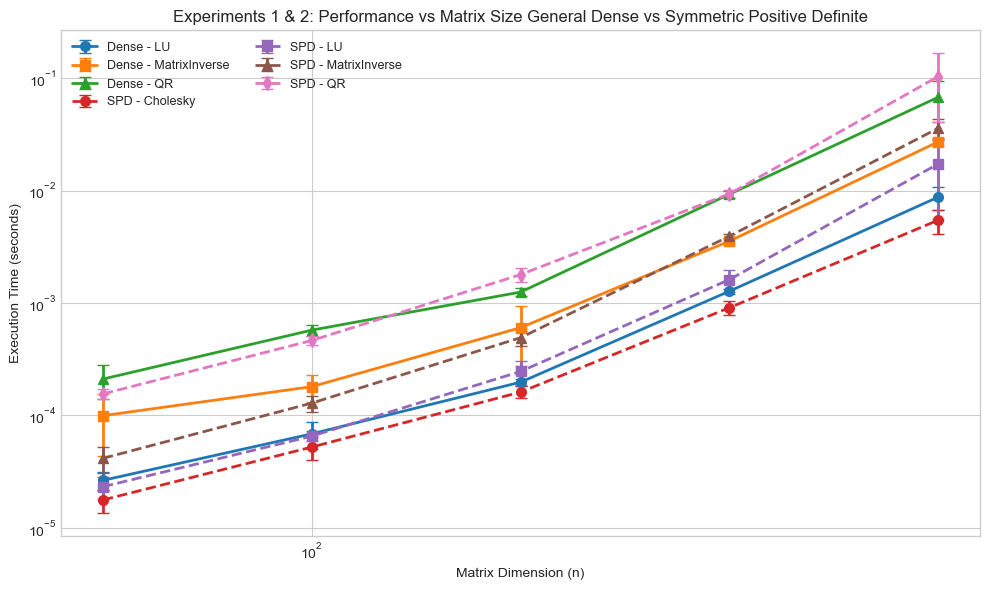

In [20]:
plot_order = [
    'Dense - LU',
    'Dense - MatrixInverse',
    'Dense - QR',
    'SPD - Cholesky',
    'SPD - LU',
    'SPD - MatrixInverse',
    'SPD - QR',
]

styles = {
    'Dense - LU': dict(marker='o', linestyle='-', linewidth=2),
    'Dense - MatrixInverse': dict(marker='s', linestyle='-', linewidth=2),
    'Dense - QR': dict(marker='^', linestyle='-', linewidth=2),
    'SPD - Cholesky': dict(marker='o', linestyle='--', linewidth=2),
    'SPD - LU': dict(marker='s', linestyle='--', linewidth=2),
    'SPD - MatrixInverse': dict(marker='^', linestyle='--', linewidth=2),
    'SPD - QR': dict(marker='d', linestyle='--', linewidth=2),
}

fig, ax = plt.subplots(figsize=(10, 6))
for method in plot_order:
    sub = summary[summary['Method'] == method].sort_values('n')
    st = styles[method]
    ax.errorbar(
        sub['n'], sub['mean_time_s'], yerr=sub['std_time_s'],
        label=method, capsize=4, ms=7, **st
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Dimension (n)')
ax.set_ylabel('Execution Time (seconds)')
ax.set_title('Experiments 1 & 2: Performance vs Matrix Size General Dense vs Symmetric Positive Definite')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## Curve fitting for all cases

For each method, estimate:
- `t(n) = a * n^b`
- `t(n) = c * n^3`


In [21]:
def fit_power_law_ab(n, t):
    n = np.asarray(n, dtype=float)
    t = np.asarray(t, dtype=float)
    b, log_a = np.polyfit(np.log(n), np.log(t), 1)
    a = np.exp(log_a)
    return float(a), float(b)


def fit_cubic_prefactor(n, t):
    n = np.asarray(n, dtype=float)
    t = np.asarray(t, dtype=float)
    x = n**3
    c = np.dot(x, t) / np.dot(x, x)
    return float(c)


def r2_score(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')


fit_rows = []
for method, sub in summary.groupby('Method'):
    sub = sub.sort_values('n')
    n = sub['n'].to_numpy(dtype=float)
    t = sub['mean_time_s'].to_numpy(dtype=float)

    a_hat, b_hat = fit_power_law_ab(n, t)
    c_hat = fit_cubic_prefactor(n, t)

    y_ab = a_hat * n**b_hat
    y_c3 = c_hat * n**3

    fit_rows.append({
        'Method': method,
        'a_hat': a_hat,
        'b_hat': b_hat,
        'c_hat_for_n3': c_hat,
        'R2_a_n_b': r2_score(t, y_ab),
        'R2_c_n3': r2_score(t, y_c3),
    })

fit_table = pd.DataFrame(fit_rows).sort_values('Method').reset_index(drop=True)
fit_table


,Method,a_hat,b_hat,c_hat_for_n3,R2_a_n_b,R2_c_n3
0,Dense - LU,4.94812e-09,2.09695,1.7153e-11,0.871117,0.999338
1,Dense - MatrixInverse,1.93478e-08,2.04981,5.31251e-11,0.821256,0.999855
2,Dense - QR,4.31798e-08,2.06867,1.32679e-10,0.830232,0.999735
3,SPD - Cholesky,4.14691e-09,2.0666,1.07143e-11,0.920668,0.997381
4,SPD - LU,1.39627e-09,2.372,3.36337e-11,0.810672,0.998703
5,SPD - MatrixInverse,1.92998e-09,2.44572,7.00215e-11,0.861622,0.999673
6,SPD - QR,1.26674e-08,2.31046,2.01544e-10,0.811667,0.99843


## Fitted formulas by method

In [22]:
formula_table = fit_table.copy()
formula_table['fit_a_n_b_formula'] = formula_table.apply(
    lambda r: f"t(n) ≈ {r['a_hat']:.6e} * n^{r['b_hat']:.6f}", axis=1
)
formula_table['fit_c_n3_formula'] = formula_table.apply(
    lambda r: f"t(n) ≈ {r['c_hat_for_n3']:.6e} * n^3", axis=1
)
formula_table[['Method', 'fit_a_n_b_formula', 'fit_c_n3_formula', 'R2_a_n_b', 'R2_c_n3']]


,Method,fit_a_n_b_formula,fit_c_n3_formula,R2_a_n_b,R2_c_n3
0,Dense - LU,t(n) ≈ 4.948123e-09 * n^2.096948,t(n) ≈ 1.715298e-11 * n^3,0.871117,0.999338
1,Dense - MatrixInverse,t(n) ≈ 1.934783e-08 * n^2.049807,t(n) ≈ 5.312510e-11 * n^3,0.821256,0.999855
2,Dense - QR,t(n) ≈ 4.317984e-08 * n^2.068674,t(n) ≈ 1.326788e-10 * n^3,0.830232,0.999735
3,SPD - Cholesky,t(n) ≈ 4.146907e-09 * n^2.066605,t(n) ≈ 1.071434e-11 * n^3,0.920668,0.997381
4,SPD - LU,t(n) ≈ 1.396272e-09 * n^2.372002,t(n) ≈ 3.363369e-11 * n^3,0.810672,0.998703
5,SPD - MatrixInverse,t(n) ≈ 1.929979e-09 * n^2.445724,t(n) ≈ 7.002152e-11 * n^3,0.861622,0.999673
6,SPD - QR,t(n) ≈ 1.266741e-08 * n^2.310465,t(n) ≈ 2.015445e-10 * n^3,0.811667,0.99843


## Curves evaluated at the benchmark sizes

In [23]:
fit_curves_rows = []
for method, sub in summary.groupby('Method'):
    sub = sub.sort_values('n')
    n = sub['n'].to_numpy(dtype=float)
    t = sub['mean_time_s'].to_numpy(dtype=float)
    a_hat, b_hat = fit_power_law_ab(n, t)
    c_hat = fit_cubic_prefactor(n, t)

    for ni, ti in zip(n, t):
        fit_curves_rows.append({
            'Method': method,
            'n': ni,
            'observed_mean_time_s': ti,
            'fit_a_n_b': a_hat * ni**b_hat,
            'fit_c_n3': c_hat * ni**3,
        })

fit_curves = pd.DataFrame(fit_curves_rows)
fit_curves


,Method,n,observed_mean_time_s,fit_a_n_b,fit_c_n3
0,Dense - LU,50,2.63667e-05,1.80756e-05,2.14412e-06
1,Dense - LU,100,6.83867e-05,7.73279e-05,1.7153e-05
2,Dense - LU,200,0.000197165,0.000330811,0.000137224
3,Dense - LU,400,0.00127223,0.00141522,0.00109779
4,Dense - LU,800,0.00875948,0.00605437,0.00878233
5,Dense - MatrixInverse,50,9.92467e-05,5.87751e-05,6.64064e-06
6,Dense - MatrixInverse,100,0.000179877,0.000243359,5.31251e-05
7,Dense - MatrixInverse,200,0.000602678,0.00100763,0.000425001
8,Dense - MatrixInverse,400,0.00355228,0.00417209,0.00340001
9,Dense - MatrixInverse,800,0.027178,0.0172746,0.0272001


## Combined graph with fitted curves

Measured curves are shown together with:
- dotted line: `a * n^b`
- dash-dot line: `c * n^3`


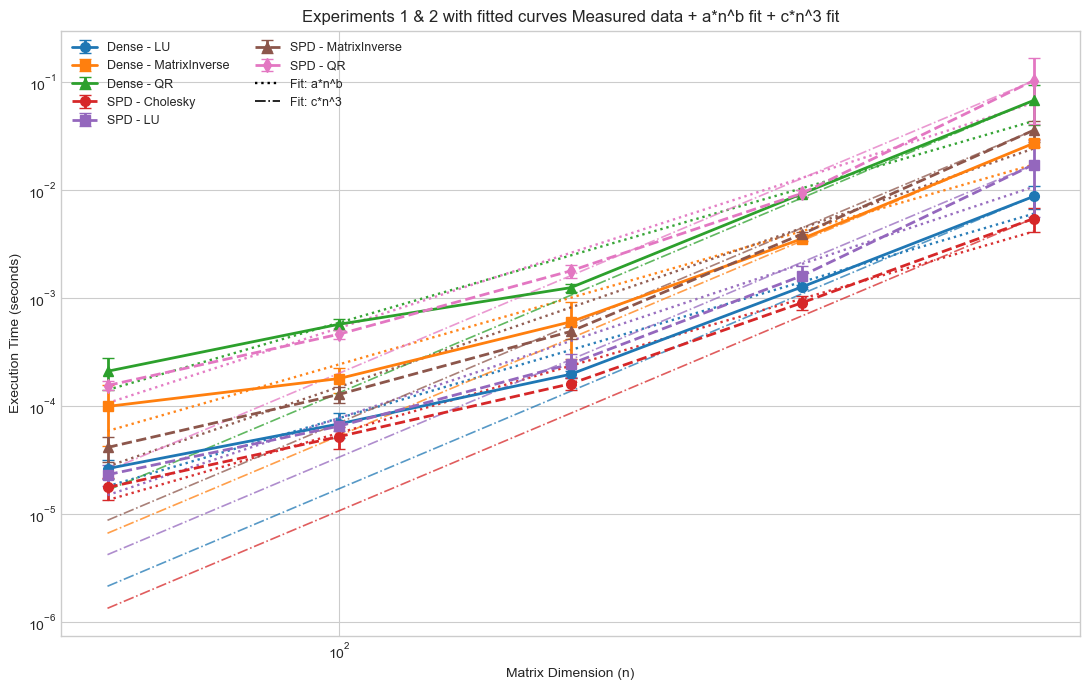

In [24]:
plot_order = [
    'Dense - LU',
    'Dense - MatrixInverse',
    'Dense - QR',
    'SPD - Cholesky',
    'SPD - LU',
    'SPD - MatrixInverse',
    'SPD - QR',
]

base_styles = {
    'Dense - LU': dict(color='C0', marker='o', linestyle='-', linewidth=2),
    'Dense - MatrixInverse': dict(color='C1', marker='s', linestyle='-', linewidth=2),
    'Dense - QR': dict(color='C2', marker='^', linestyle='-', linewidth=2),
    'SPD - Cholesky': dict(color='C3', marker='o', linestyle='--', linewidth=2),
    'SPD - LU': dict(color='C4', marker='s', linestyle='--', linewidth=2),
    'SPD - MatrixInverse': dict(color='C5', marker='^', linestyle='--', linewidth=2),
    'SPD - QR': dict(color='C6', marker='d', linestyle='--', linewidth=2),
}

fig, ax = plt.subplots(figsize=(11, 7))
for method in plot_order:
    sub = summary[summary['Method'] == method].sort_values('n')
    st = base_styles[method]
    color = st['color']

    ax.errorbar(
        sub['n'], sub['mean_time_s'], yerr=sub['std_time_s'],
        label=method, capsize=4, ms=7, marker=st['marker'],
        linestyle=st['linestyle'], linewidth=st['linewidth'], color=color
    )

    n = sub['n'].to_numpy(dtype=float)
    t = sub['mean_time_s'].to_numpy(dtype=float)
    a_hat, b_hat = fit_power_law_ab(n, t)
    c_hat = fit_cubic_prefactor(n, t)

    n_smooth = np.geomspace(n.min(), n.max(), 200)
    ax.plot(n_smooth, a_hat * n_smooth**b_hat, color=color, linestyle=':', linewidth=1.7, alpha=0.95)
    ax.plot(n_smooth, c_hat * n_smooth**3, color=color, linestyle='-.', linewidth=1.2, alpha=0.75)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Dimension (n)')
ax.set_ylabel('Execution Time (seconds)')
ax.set_title('Experiments 1 & 2 with fitted curves Measured data + a*n^b fit + c*n^3 fit')

fit_legend = [
    Line2D([0], [0], color='black', linestyle=':', linewidth=1.7, label='Fit: a*n^b'),
    Line2D([0], [0], color='black', linestyle='-.', linewidth=1.2, label='Fit: c*n^3'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + fit_legend, labels + ['Fit: a*n^b', 'Fit: c*n^3'], ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## Optional: save the combined plot

Uncomment the last line if you want a PNG output as well.


In [25]:
# fig.savefig('experiments_1_2_combined_with_fits.png', dpi=200, bbox_inches='tight')


ADAPTIVE BENCHMARK RESULTS
n=  50 | time=4.265800e-05s | repeats=50 | rel_95_half_width=24.61% | residual=2.59e-15
n= 100 | time=6.527600e-05s | repeats=50 | rel_95_half_width=11.65% | residual=1.48e-14
n= 200 | time=2.228500e-04s | repeats=10 | rel_95_half_width=4.05% | residual=2.32e-13
n= 400 | time=1.419754e-03s | repeats=50 | rel_95_half_width=10.67% | residual=9.73e-14
n= 800 | time=8.854252e-03s | repeats=50 | rel_95_half_width=21.95% | residual=4.84e-13

FITS
Fit to c*n^3: c = 1.737141e-11, R^2 = 0.998147
Fit to a*n^b: a = 1.032041e-08, b = 1.983777, R^2 = 0.851578


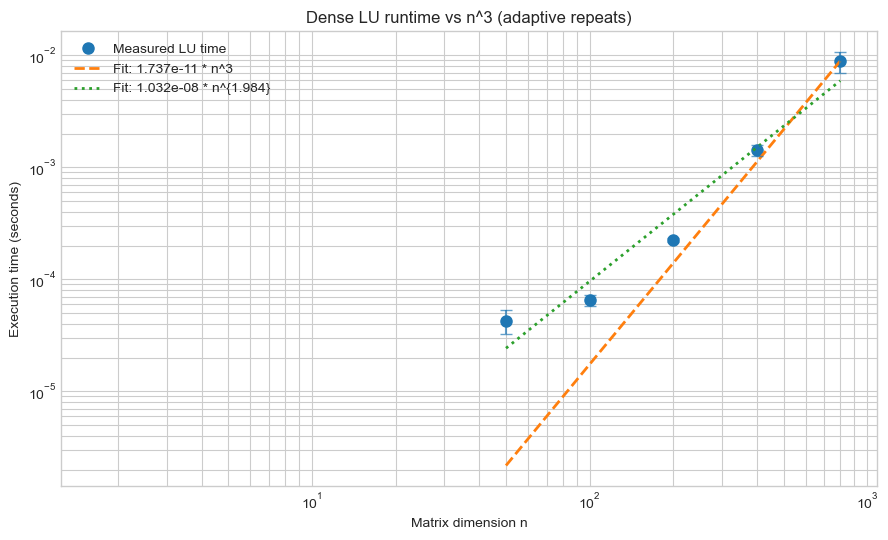

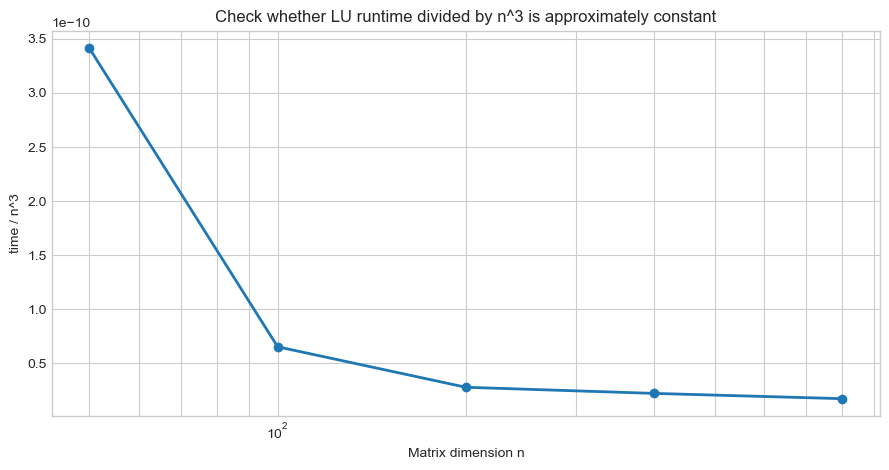

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.linalg import lu_factor, lu_solve

# =========================================================
# CONFIGURATION
# =========================================================
DIMENSIONS = [50, 100, 200, 400, 800]
REL_TOL = 0.05          # stop when 95% CI half-width <= 5% of mean
MIN_REPEATS = 10
MAX_REPEATS = 50
WARMUPS = 2
SEED = 42

# =========================================================
# SOLVER
# =========================================================
def solve_lu(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    lu, piv = lu_factor(A, check_finite=False)
    return lu_solve((lu, piv), b, check_finite=False)

# =========================================================
# MATRIX GENERATOR
# =========================================================
def generate_general_dense(n: int, rng: np.random.Generator):
    # Add 5*I to make the system comfortably nonsingular
    A = rng.standard_normal((n, n)) + 5.0 * np.eye(n)
    b = rng.standard_normal(n)
    return A, b

# =========================================================
# ADAPTIVE BENCHMARKING
# =========================================================
def benchmark_solver_adaptive(
    solver,
    A: np.ndarray,
    b: np.ndarray,
    rel_tol: float = 0.05,
    min_repeats: int = 10,
    max_repeats: int = 50,
    warmups: int = 2,
):
    # Warmup runs (not counted)
    for _ in range(warmups):
        solver(A, b)

    times = []
    x_last = None

    for _ in range(max_repeats):
        t0 = perf_counter()
        x_last = solver(A, b)
        times.append(perf_counter() - t0)

        r = len(times)
        if r < min_repeats:
            continue

        mean_t = np.mean(times)
        std_t = np.std(times, ddof=1)
        se_t = std_t / np.sqrt(r)

        # Approximate 95% confidence half-width
        half_width_95 = 1.96 * se_t
        rel_half_width_95 = half_width_95 / mean_t

        if rel_half_width_95 <= rel_tol:
            break

    times = np.array(times, dtype=float)
    mean_t = float(np.mean(times))
    std_t = float(np.std(times, ddof=1)) if len(times) > 1 else 0.0
    se_t = std_t / np.sqrt(len(times)) if len(times) > 1 else 0.0
    half_width_95 = 1.96 * se_t if len(times) > 1 else 0.0
    rel_half_width_95 = half_width_95 / mean_t if mean_t > 0 else np.nan

    rel_residual = np.linalg.norm(A @ x_last - b) / np.linalg.norm(b)

    return {
        "mean_time_s": mean_t,
        "std_time_s": std_t,
        "repeats_used": len(times),
        "half_width_95_s": float(half_width_95),
        "rel_half_width_95": float(rel_half_width_95),
        "rel_residual": float(rel_residual),
        "all_times": times,
    }

# =========================================================
# RUN EXPERIMENT
# =========================================================
def run_lu_scaling_experiment_adaptive(
    dimensions,
    rel_tol: float = 0.05,
    min_repeats: int = 10,
    max_repeats: int = 50,
    warmups: int = 2,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    rows = []

    for n in dimensions:
        A, b = generate_general_dense(int(n), rng)

        out = benchmark_solver_adaptive(
            solve_lu,
            A,
            b,
            rel_tol=rel_tol,
            min_repeats=min_repeats,
            max_repeats=max_repeats,
            warmups=warmups,
        )

        rows.append({
            "n": int(n),
            "mean_time_s": out["mean_time_s"],
            "std_time_s": out["std_time_s"],
            "repeats_used": out["repeats_used"],
            "half_width_95_s": out["half_width_95_s"],
            "rel_half_width_95": out["rel_half_width_95"],
            "rel_residual": out["rel_residual"],
        })

    return rows

results = run_lu_scaling_experiment_adaptive(
    dimensions=DIMENSIONS,
    rel_tol=REL_TOL,
    min_repeats=MIN_REPEATS,
    max_repeats=MAX_REPEATS,
    warmups=WARMUPS,
    seed=SEED,
)

# =========================================================
# EXTRACT RESULTS
# =========================================================
n = np.array([row["n"] for row in results], dtype=float)
t = np.array([row["mean_time_s"] for row in results], dtype=float)
t_std = np.array([row["std_time_s"] for row in results], dtype=float)
t_err95 = np.array([row["half_width_95_s"] for row in results], dtype=float)

# =========================================================
# FIT t ~ c * n^3
# =========================================================
x_cubic = n**3
c_hat = np.dot(x_cubic, t) / np.dot(x_cubic, x_cubic)
t_cubic = c_hat * n**3

# =========================================================
# FIT t ~ a * n^b
# =========================================================
b_hat, log_a_hat = np.polyfit(np.log(n), np.log(t), 1)
a_hat = np.exp(log_a_hat)
t_power = a_hat * n**b_hat

# =========================================================
# DIAGNOSTICS
# =========================================================
def r2(y, yhat):
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res / ss_tot

r2_cubic = r2(t, t_cubic)
r2_power = r2(t, t_power)

ratio = t / n**3

print("=========================================================")
print("ADAPTIVE BENCHMARK RESULTS")
print("=========================================================")
for row in results:
    print(
        f"n={row['n']:4d} | "
        f"time={row['mean_time_s']:.6e}s | "
        f"repeats={row['repeats_used']:2d} | "
        f"rel_95_half_width={row['rel_half_width_95']:.2%} | "
        f"residual={row['rel_residual']:.2e}"
    )

print("\n=========================================================")
print("FITS")
print("=========================================================")
print(f"Fit to c*n^3: c = {c_hat:.6e}, R^2 = {r2_cubic:.6f}")
print(f"Fit to a*n^b: a = {a_hat:.6e}, b = {b_hat:.6f}, R^2 = {r2_power:.6f}")

# =========================================================
# PLOTS
# =========================================================
n_smooth = np.geomspace(n.min(), n.max(), 300)

# Plot 1: measured LU times + fits
plt.figure(figsize=(9, 5.5))
plt.loglog(n, t, "o", ms=8, label="Measured LU time")
plt.loglog(n_smooth, c_hat * n_smooth**3, "--", lw=2,
           label=fr"Fit: {c_hat:.3e} * n^3")
plt.loglog(n_smooth, a_hat * n_smooth**b_hat, ":", lw=2,
           label=fr"Fit: {a_hat:.3e} * n^{{{b_hat:.3f}}}")

# optional error bars
plt.errorbar(n, t, yerr=t_err95, fmt="none", capsize=4, alpha=0.7)

plt.xlabel("Matrix dimension n")
plt.ylabel("Execution time (seconds)")
plt.title("Dense LU runtime vs n^3 (adaptive repeats)")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: t / n^3
plt.figure(figsize=(9, 4.8))
plt.semilogx(n, ratio, "o-", lw=2)
plt.xlabel("Matrix dimension n")
plt.ylabel("time / n^3")
plt.title("Check whether LU runtime divided by n^3 is approximately constant")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()